In [1]:
import numpy as np

In [38]:
def gradient_clipping_with_gloabl_norm(gradients,threshold_c):
    tota_squared_norm=sum(np.sum(np.square(g) for g in gradients))
    gloabl_norm=np.sqrt(tota_squared_norm)
    coef=threshold_c/(gloabl_norm*1e-6)

    if coef<1.0:
        gradients=[g*coef for g in gradients]
    return gradients,gloabl_norm

def train_with_momentum(x_train,y_train,lr=0.001,beta=0.9,epochs=1000,threshold_c=1.0):
    m,n=x_train.shape

    w=np.random.randn(n,1)*0.01
    b=0.0
    losses=[]
    v_w=np.zeros_like(w)
    v_b=np.zeros_like(b)

    for epoch in range(epochs):
        pred=x_train@w+b

        error=pred-y_train
        loss=(1/2*m)*np.sum(np.square(pred-y_train))
        dw=(1/m)*x_train.T@error
        db=(1/m)*np.sum(error)

        clipped_gradient,_=gradient_clipping_with_gloabl_norm([dw,db],threshold_c)
        dw_clipped,db_clipped=clipped_gradient

        v_w=beta*v_w + ((1-beta) * dw_clipped)
        v_b=beta*v_b + ((1-beta) * db_clipped)

        w-=lr*v_w
        b-=lr*v_b
        losses.append(loss)
        if epoch %100 ==0:
            print(f"Epoch :{epoch} | Loss :{loss}")

    return w,b,losses
    

    
        

In [39]:
x_train=np.random.randn(1000,4)
y_train=np.dot(x_train,np.array([[1],[-2],[3],[0.1]]))+1.5+(np.random.randn(1000,1)*0.1)

In [40]:
x_train.shape

(1000, 4)

In [41]:
y_train.shape

(1000, 1)

In [42]:
train_w,train_b,losses=train_with_momentum(x_train,y_train,lr=0.1,beta=0.9,threshold_c=5.0)

Epoch :0 | Loss :8463925.330502076
Epoch :100 | Loss :5005.682215510649
Epoch :200 | Loss :4884.2582001183655
Epoch :300 | Loss :4884.256071378384
Epoch :400 | Loss :4884.256071301233
Epoch :500 | Loss :4884.256071301231
Epoch :600 | Loss :4884.256071301229
Epoch :700 | Loss :4884.256071301231
Epoch :800 | Loss :4884.256071301231
Epoch :900 | Loss :4884.256071301231


C:\Users\hp 840 G5\AppData\Local\Temp\ipykernel_38980\118333065.py:2: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  tota_squared_norm=sum(np.sum(np.square(g) for g in gradients))


In [43]:
train_b,train_w

(1.504868881570076,
 array([[ 0.996621  ],
        [-1.99923536],
        [ 3.00034473],
        [ 0.10185343]]))

In [44]:
np.array([[1,2,3,4]])@+train_w+train_b

array([[7.91146708]])

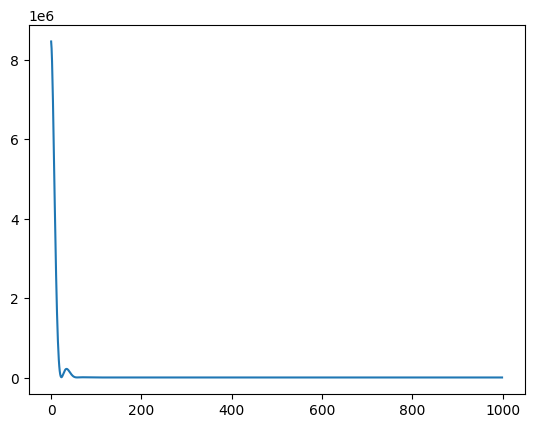

In [45]:
import matplotlib.pyplot as plt
plt.plot(losses)

In [96]:
class GDwGC:
    def __init__(self,n,m,threshold_c,lr=0.01,beta=0.9):
        self.m=m
        self.w=np.random.randn(n,1)*0.01
        self.b=0.0
        self.v_w=np.zeros_like(self.w)
        self.v_b=np.zeros_like(self.b)
        self.threshold_c=threshold_c
        self.lr=lr
        self.beta=beta
        self.losses=[]


    def forward(self,x_train):
        pred=x_train@self.w+self.b

        return pred

    def compute_error(self,pred,y_train):
        error=pred-y_train
        return error

    def compute_gradients(self,error,x_train):
        dw=(1/self.m)*x_train.T@error
        db=(1/self.m)*np.sum(error)
        return dw,db
    def clip_gradient_function(self,gradients):
        squared_grad=sum(np.sum(np.square(g)) for g in gradients)
        global_gradient=np.sqrt(squared_grad)
        coef=self.threshold_c/(global_gradient+1e-6)

        if coef<1.0:
            gradients=[g*coef for g in gradients]

        
        return gradients,global_gradient

    def compute_velocity(self,dw,db):
        self.v_w=(self.beta*self.v_w) + ((1-self.beta) * dw)
        self.v_b=(self.beta*self.v_b) + ((1-self.beta) * db)
        

    def update_peramaters(self):
        self.w-=self.lr*self.v_w
        self.b-=self.lr*self.v_b
        
    def get_losses(self,x_train,y_train):
        pred=self.forward(x_train)
        error=self.compute_error(pred,y_train)
        loss=(1/(2*self.m))*np.sum(np.square(error))

        return loss
        

    
        

        

In [109]:
m,n=x_train.shape

In [110]:
model=GDwGC(n,m,threshold_c=5.0)

In [111]:
losses=[]
for epoch in range(1000):

    pred=model.forward(x_train)
    error=model.compute_error(pred,y_train)
    dw,db=model.compute_gradients(error,x_train)
    (dw_clipped,db_clipped),_=model.clip_gradient_function([dw,db])
    model.compute_velocity(dw_clipped,db_clipped)
    model.update_peramaters()
    loss=model.get_losses(x_train,y_train)
    losses.append(loss)
    if epoch % 50==0:
        print(f"Epoch :{epoch}  |  Loss :{loss}")

Epoch :0  |  Loss :8.365101272419093
Epoch :50  |  Loss :3.2779055173515816
Epoch :100  |  Loss :1.0302301421057674
Epoch :150  |  Loss :0.326199133636682
Epoch :200  |  Loss :0.10594670478602619
Epoch :250  |  Loss :0.03678623808419815
Epoch :300  |  Loss :0.014989839349413437
Epoch :350  |  Loss :0.008096207891244213
Epoch :400  |  Loss :0.0059084687302785755
Epoch :450  |  Loss :0.005211880151981477
Epoch :500  |  Loss :0.004989374431009853
Epoch :550  |  Loss :0.004918082198852339
Epoch :600  |  Loss :0.004895171781660253
Epoch :650  |  Loss :0.004887788178481573
Epoch :700  |  Loss :0.004885401993043415
Epoch :750  |  Loss :0.004884628783100552
Epoch :800  |  Loss :0.004884377591092796
Epoch :850  |  Loss :0.004884295784586813
Epoch :900  |  Loss :0.004884269078967376
Epoch :950  |  Loss :0.004884260341008575


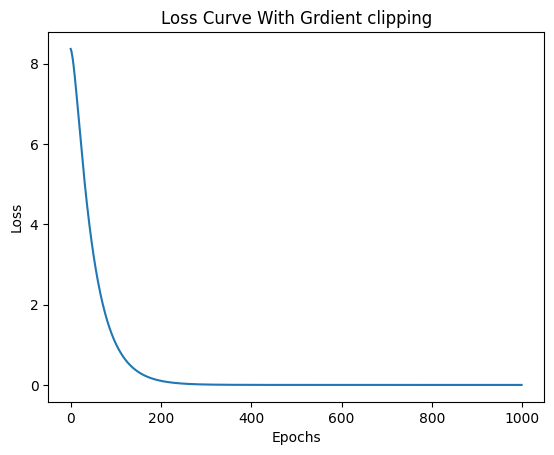

In [112]:
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve With Grdient clipping")
plt.show()